In [43]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [44]:
condition = "first_try"
checkpoint_epoch = 0
n_samples_test = 30

split = "train"

experiment_name = get_experiment_name(condition, "biased_00", 0)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, nb_module=3)
data_module = get_data_module("syn",  experiment_name, nb_module=3)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
original_colors = test_samples[frozenset({'color', 'v_latents', 'attr'})]['color']
original_attr = test_samples[frozenset({'color', 'v_latents', 'attr'})]['attr']
original_v_latents = test_samples[frozenset({'color', 'v_latents', 'attr'})]['v_latents']

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

original_images_rgb = visual_module.decode_images(original_v_latents)


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/first_try_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/first_try_biased_00/checkpoints/last.ckpt


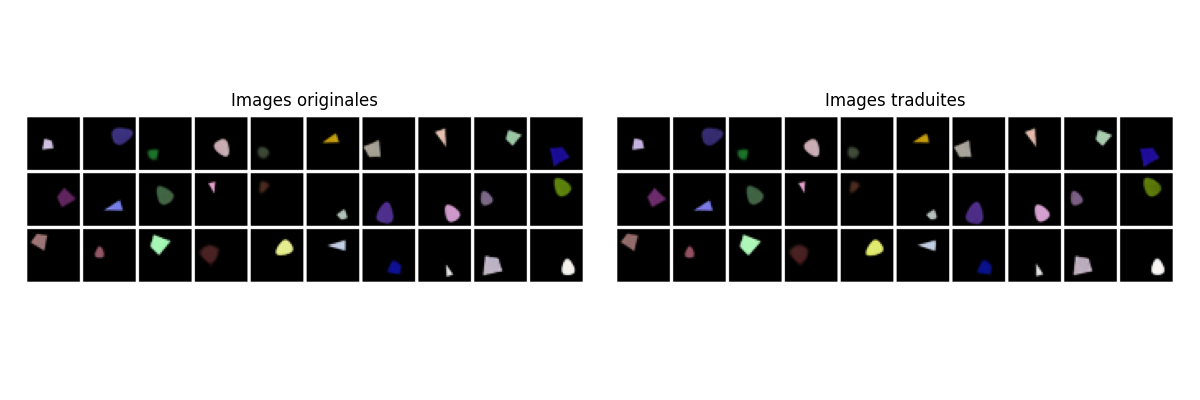

In [45]:
# demi cycle v_latents
domain_name_source = 'v_latents'
latents_source = latent_domains[frozenset({domain_name_source})]

z = gw_mod.encode(latents_source)[domain_name_source]
dcy = gw_mod.decode(z, domains={domain_name_source})
decoded_images_dcy= visual_module.decode_images(dcy['v_latents'])

fig = plot_original_translated_comparison(original_images_rgb, decoded_images_dcy)
plt.show()


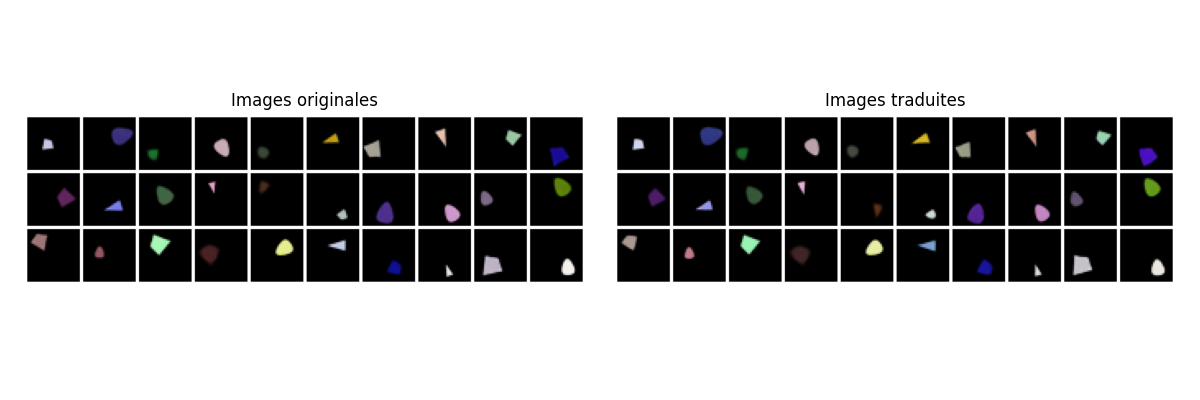

In [46]:

latents_source = latent_domains[frozenset({'color', 'v_latents', 'attr'})]

gw_latents = gw_mod.encode(latents_source)
z = 0.5*gw_latents['color'] + 0.5*gw_latents['attr']

prediction = gw_mod.decode(z, domains={'v_latents'})['v_latents']
decoded_images_f= visual_module.decode_images(prediction)

fig = plot_original_translated_comparison(original_images_rgb, decoded_images_f)
plt.show()
